## **PART A -- Baseline Foundations on NLP**

## **TASK 1: Data Loading AND Preparation**

* **Dataset**
* **Split**
* **Structure**

Provided with 3 seperate text files: `train.txt`, `val.txt` and `test.txt`

All datasets contain 6 distinct emotions (Anger, Fear, Love, Joy, Sadness or Suprise). 

In [1]:
print('='*50)
print("Part A - Task 1: Data Loading & Preparation")
print('='*50)
print()

#Import Libraries

#----Core Libraries----
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

#----NLTK Libraries----
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#----Sckit-Learn: Feature Extraction Text----
from sklearn.feature_extraction.text import TfidfVectorizer

#----Tensorflow Libraries----
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#----Scikit-Learn: Metrics----
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Set nltk language to 'english'
nltk_stopwords = stopwords.words('english')

print('Libraries imported!')

Part A - Task 1: Data Loading & Preparation

Libraries imported!


In [2]:
#Set the directories as variable for efficiency
TRAIN_FILE = './data/train.txt'
VALID_FILE = './data/val.txt'
TEST_FILE = './data/test.txt'

print("File Directories as variables set!")

File Directories as variables set!


In [3]:
#Load the 3 data files of Train, Valid and Test.txt
df01 = pd.read_table(TRAIN_FILE, sep=';', header=None, names=['text', 'labels'])
print("train.txt")
display(df01.head())

df02 = pd.read_table(VALID_FILE, sep=';', header=None, names=['text', 'labels'])
print("val.txt")
display(df02.head())

df03 = pd.read_table(TEST_FILE, sep=';', header=None, names=['text', 'labels'])
print("test.txt")
display(df03.head())

print("Loading & Preparation executed!")

train.txt


,text,labels
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


val.txt


,text,labels
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


test.txt


,text,labels
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


Loading & Preparation executed!


## **TASK 2: Text Preprocessing & Vectorization**

* **Cleaning & Preprocessing**
* **Vectorization**


In [4]:
def clean(input_text):
    output_text = str(input_text).translate(str.maketrans('', '', string.punctuation))
    output_text = output_text.lower()
    output_text = re.sub(r'\d+', '', output_text)
    return output_text

def lemm_text(input_text):
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(input_text)
    words = [word for word in words if word.lower() not in nltk_stopwords]
    lemmatize_words = [lemmatizer.lemmatize(word) for word in words]
    lemm_output = ' '.join(lemmatize_words)
    return lemm_output

def process_with_lemm(input_text):
    output_text = clean(input_text)
    final_text = lemm_text(output_text)
    return final_text

In [5]:
print('='*50)
print("Part A - TASK 2: Text Preprocessing & Vectorization")
print('='*50)
print()

df01_clean = df01.copy()
df01_clean['clean_text'] = df01_clean['text'].apply(process_with_lemm)

df02_clean = df02.copy()
df02_clean['clean_text'] = df02_clean['text'].apply(process_with_lemm)

df03_clean = df03.copy()
df03_clean['clean_text'] = df03_clean['text'].apply(process_with_lemm)


print("train.txt (Cleaned Version)")
display(df01_clean[['clean_text', 'labels']].head())
print()
print("Cleaning Done!")

Part A - TASK 2: Text Preprocessing & Vectorization

train.txt (Cleaned Version)


,clean_text,labels
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger



Cleaning Done!


In [6]:
print('='*50)
print("Part A - Task 2: Vectorization")
print('='*50)
print()
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train = tfidf_vectorizer.fit_transform(df01_clean['clean_text'])
X_val = tfidf_vectorizer.transform(df02_clean['clean_text'])
X_test = tfidf_vectorizer.transform(df03_clean['clean_text'])

y_train = pd.get_dummies(df01_clean['labels'])
y_val = pd.get_dummies(df02_clean['labels'])
y_test = pd.get_dummies(df03_clean['labels'])

print("Vectorization completed!")

Part A - Task 2: Vectorization

Vectorization completed!


In [7]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 134310 stored elements and shape (16000, 5000)>

In [8]:
y_train.head()

,anger,fear,joy,love,sadness,surprise
0,False,False,False,False,True,False
1,False,False,False,False,True,False
2,True,False,False,False,False,False
3,False,False,False,True,False,False
4,True,False,False,False,False,False


## **TASK 3: Baseline Neural Network**

* **Architecture**
* **Training**

In [9]:
model = Sequential()

model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

model.add(Dense(y_train.shape[1], activation='softmax'))

c:\Users\Zach Ng\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
num_epochs = 5
history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val))

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6147 - loss: 1.2153 - val_accuracy: 0.8275 - val_loss: 0.6741
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9066 - loss: 0.3892 - val_accuracy: 0.8870 - val_loss: 0.3583
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9549 - loss: 0.1867 - val_accuracy: 0.8880 - val_loss: 0.3162
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9707 - loss: 0.1212 - val_accuracy: 0.8935 - val_loss: 0.3137
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0874 - val_accuracy: 0.8870 - val_loss: 0.3259


## **TASK 4: Evaluation & Metrics**

* **Curves**
* **Testing**
* **Visualization**

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8775 - loss: 0.3244
Accuracy: 0.8774999976158142


In [13]:
print(y_test.shape)

print(y_test[0:5])

(2000, 6)
   anger   fear    joy   love  sadness  surprise
0  False  False  False  False     True     False
1  False  False  False  False     True     False
2  False  False  False  False     True     False
3  False  False   True  False    False     False
4  False  False  False  False     True     False


In [14]:
preds = model.predict(X_test)

print(preds.shape)
print()
print(preds[0:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(2000, 6)

[[1.22259266e-03 1.46084290e-04 2.23273877e-04 1.11561218e-04
  9.98203754e-01 9.28234585e-05]
 [2.55568593e-04 1.39668655e-05 2.82849942e-05 3.42995872e-06
  9.99692678e-01 6.05966397e-06]
 [1.97733683e-03 6.34105736e-03 1.90256406e-02 9.96473012e-04
  9.71081614e-01 5.77976287e-04]
 [6.31152093e-03 4.65598563e-03 9.83278215e-01 4.82540025e-04
  3.55668669e-03 1.71509723e-03]
 [2.18029672e-05 5.93916520e-05 1.01379039e-04 3.65474648e-06
  9.99797523e-01 1.61663775e-05]]


In [15]:
preds_cm = [np.argmax(each) for each in preds]
print(preds_cm[0:5])
print()
y_preds_cm = [np.argmax(each) for each in y_test.values]
print(y_preds_cm)

[np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4)]

[np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(4), np.int64(0), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(0), np.int64(4), np.int64(2), np.int64(4), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(4), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(5), np.int64(4), np.int64(0), np.int64(1), np.int64(5), np.int64(2), np.int64(

In [16]:
emotion_labels = sorted(df01_clean['labels'].unique())
print("Labels:", emotion_labels)

Labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [17]:
cm = confusion_matrix(y_preds_cm, preds_cm)
cm

array([[244,   6,   8,   0,  17,   0],
       [ 14, 178,   8,   0,  15,   9],
       [  2,   4, 642,  36,   7,   4],
       [  3,   1,  29, 122,   4,   0],
       [ 25,   6,  25,   1, 524,   0],
       [  3,   8,   7,   0,   3,  45]])

In [18]:
df_cm = pd.DataFrame(cm, index=emotion_labels, columns=emotion_labels)
print(df_cm)

          anger  fear  joy  love  sadness  surprise
anger       244     6    8     0       17         0
fear         14   178    8     0       15         9
joy           2     4  642    36        7         4
love          3     1   29   122        4         0
sadness      25     6   25     1      524         0
surprise      3     8    7     0        3        45


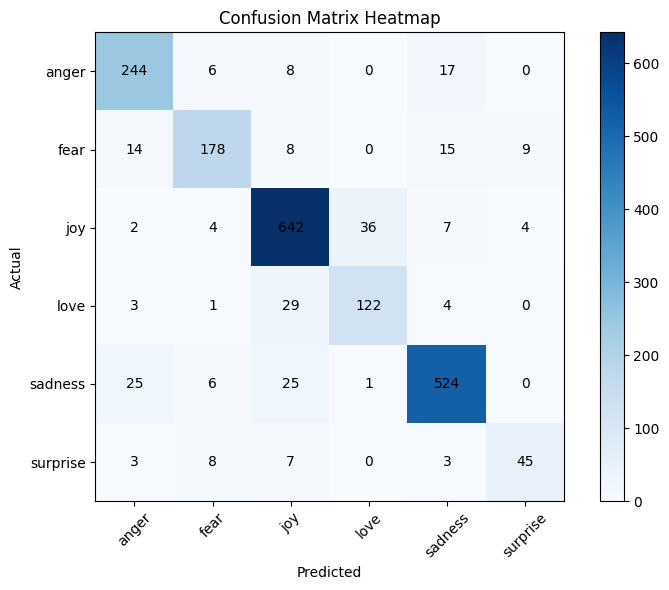

In [19]:
#Plot Heatmap
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(6), emotion_labels, rotation=45)
plt.yticks(range(6), emotion_labels)

for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
print(classification_report(y_preds_cm, preds_cm, target_names=emotion_labels))

print('='*50)
print("Evaluation & Metrics Complete")
print('='*50)

              precision    recall  f1-score   support

       anger       0.84      0.89      0.86       275
        fear       0.88      0.79      0.83       224
         joy       0.89      0.92      0.91       695
        love       0.77      0.77      0.77       159
     sadness       0.92      0.90      0.91       581
    surprise       0.78      0.68      0.73        66

    accuracy                           0.88      2000
   macro avg       0.85      0.83      0.83      2000
weighted avg       0.88      0.88      0.88      2000

Evaluation & Metrics Complete


Loss and Accuracy Curves (Baseline)


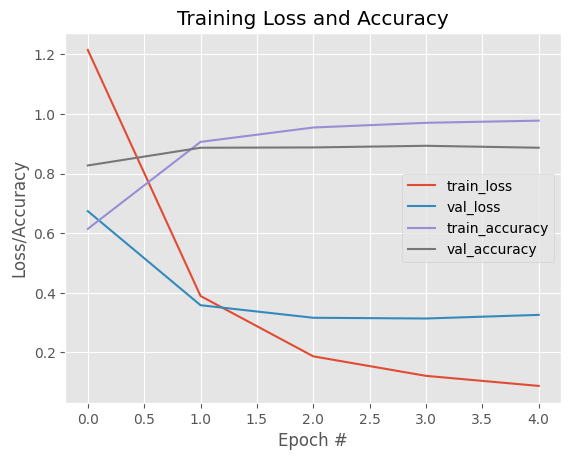

In [21]:
print('='*50)
print("Loss and Accuracy Curves (Baseline)")
print('='*50)

def plot_graphs(H, metric):
    plt.style.use('ggplot')
    plt.figure()
    plt.plot(np.arange(0, num_epochs), H.history['loss'], label="train_loss")
    plt.plot(np.arange(0, num_epochs), H.history['val_loss'], label="val_loss")
    plt.plot(np.arange(0, num_epochs), H.history['accuracy'], label="train_accuracy")
    plt.plot(np.arange(0, num_epochs), H.history['val_accuracy'], label="val_accuracy")
    plt.title('Training Loss and Accuracy')
    plt.xlabel('Epoch #')
    plt.ylabel('Loss/Accuracy')
    plt.legend()
    plt.show()
plot_graphs(history, 'accuracy')

## **TASK 5: Testing on Unseen Data**

* **Live Prediction**

In [22]:
def encode_sentence(input_text):
    cleaned_text = process_with_lemm(input_text)
    encoded_text = tfidf_vectorizer.transform([cleaned_text])
    encoded_text = encoded_text.toarray()
    return encoded_text

def prediction(encoded_text):
    emotion_labels = sorted(df01_clean['labels'].unique())
    predictions = model.predict(encoded_text)
    predicted_class = np.argmax(predictions)
    print("The predicted probability is:", predictions)
    print("The predicted class is:", predicted_class)
    print("The predicted emotion is:", emotion_labels[predicted_class])

In [23]:
print('='*50)
print("  Task 5: Testing on Unseen Data")
print('='*50)

new_text = "I am so incredibly angry right now!"
encoded = encode_sentence(new_text)
prediction(encoded)

print('='*50)
print("Testing on Unseen Sentences Complete!")
print('='*50)

  Task 5: Testing on Unseen Data
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The predicted probability is: [[0.91309863 0.01173583 0.00647747 0.00092666 0.05932217 0.00843927]]
The predicted class is: 0
The predicted emotion is: anger
Testing on Unseen Sentences Complete!


## **PART B -- Exploration on NLP Advanced Techniques**

## **Avenue 1: Deep Data Exploration & Linguistic Analysis**

## **PART B - TASK 1: Extra Imports of Libraries**

In [24]:
print('='*50)
print("  Part B - TASK 1: Setups & Extra Imports")
print('='*50)

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
nltk.download('averaged_perceptron_tagger_eng')

print()
print(f"Emotions: {emotion_labels}")
print()
print("Setup of Extra Libraries and Imports Done!")

  Part B - TASK 1: Setups & Extra Imports

Emotions: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

Setup of Extra Libraries and Imports Done!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Zach Ng\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## **PART B - TASK 2: Deep Data Exploration**

Top Words Per Emotion

  Part B - TASK 2: Top words per emotion


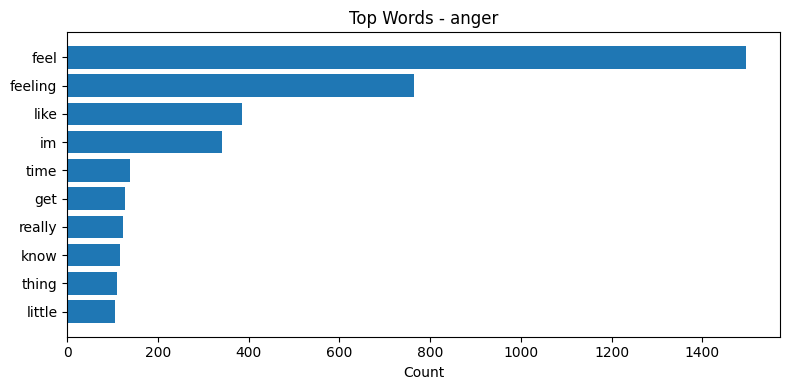

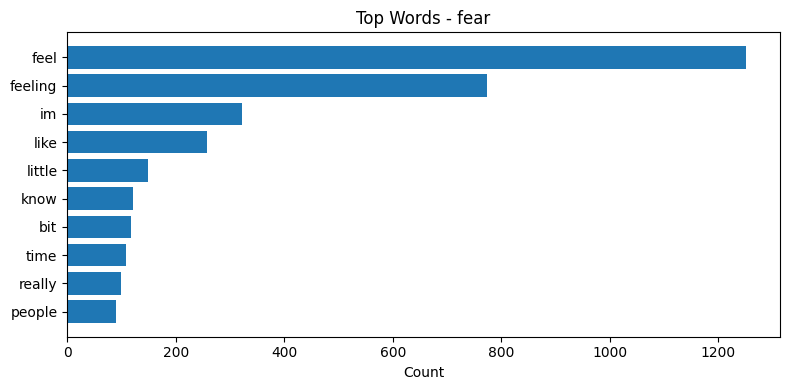

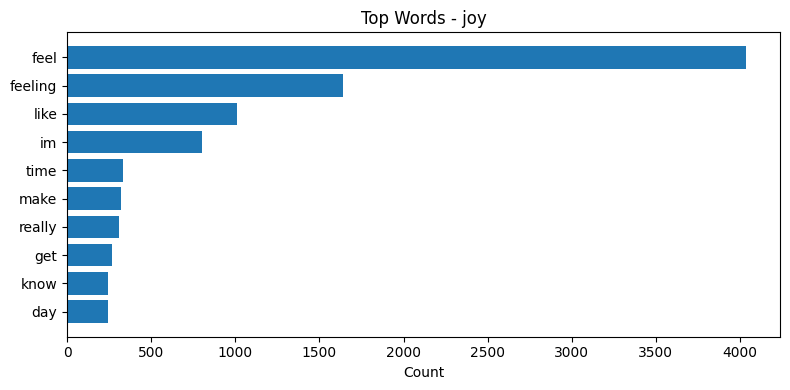

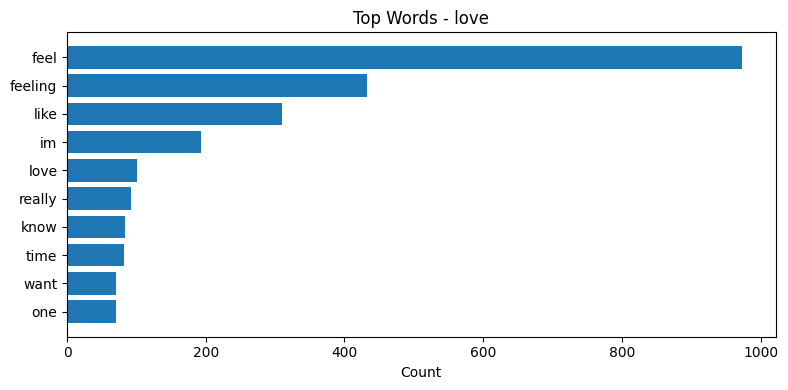

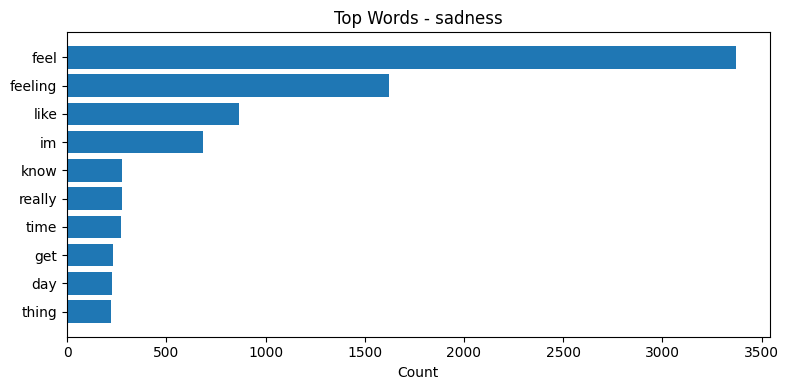

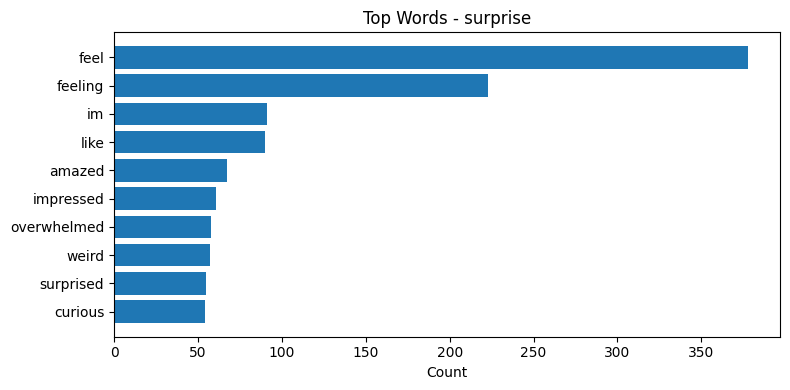


Top words per emotion done!


In [25]:
print('='*50)
print("  Part B - TASK 2: Top words per emotion")
print('='*50)

for emotion in emotion_labels:
    emotion_texts = df01_clean[df01_clean['labels']==emotion]['clean_text']

    all_words = ' '.join(emotion_texts).split()
    words_counts = Counter(all_words)
    top_words = words_counts.most_common(10)

    words = [items[0] for items in top_words]
    counts = [items[1] for items in top_words]
    
    with plt.style.context('default'):
     plt.figure(figsize=(8, 4))
     plt.barh(words[::-1], counts[::-1])
     plt.title(f'Top Words - {emotion}')
     plt.xlabel('Count')
     plt.tight_layout()
     plt.show()
print()
print('='*50)
print("Top words per emotion done!")
print('='*50)

Top Bigrams per Emotion

  Part B - TASK 2: Top Bigrams per emotion


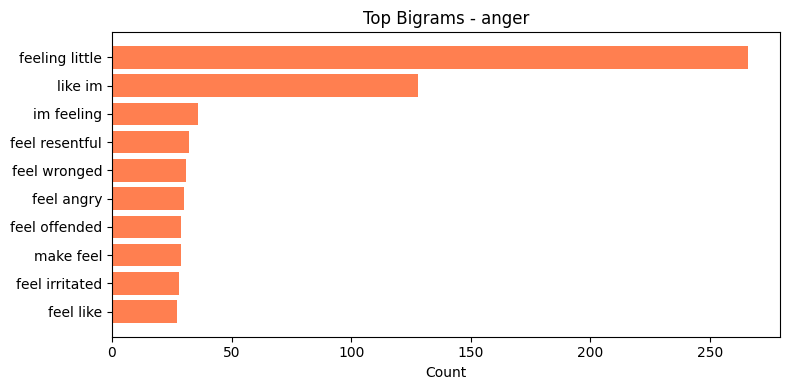

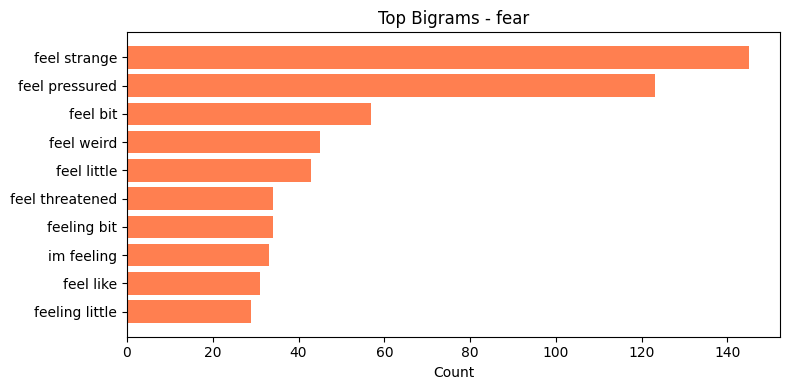

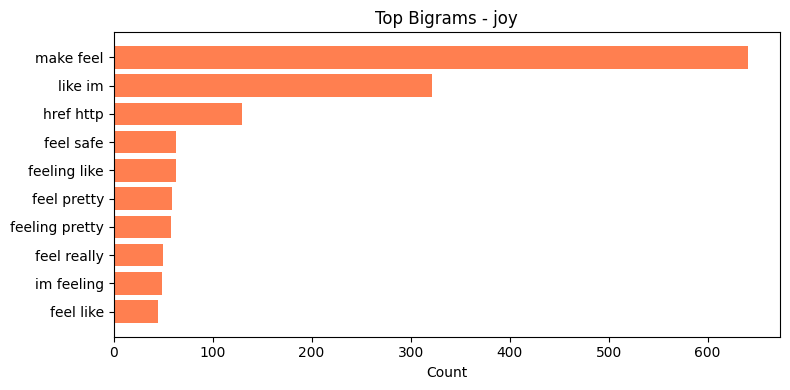

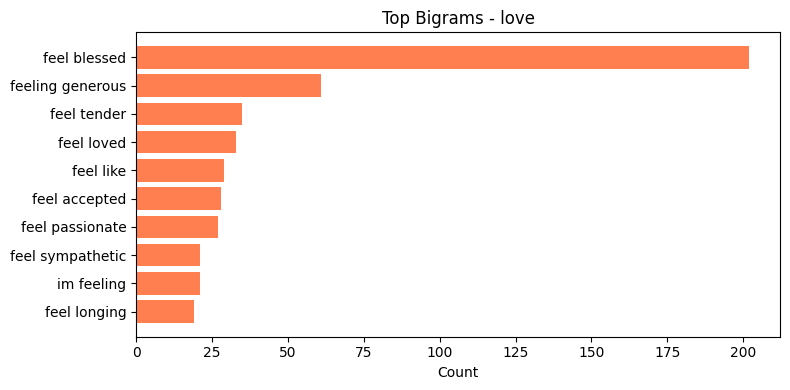

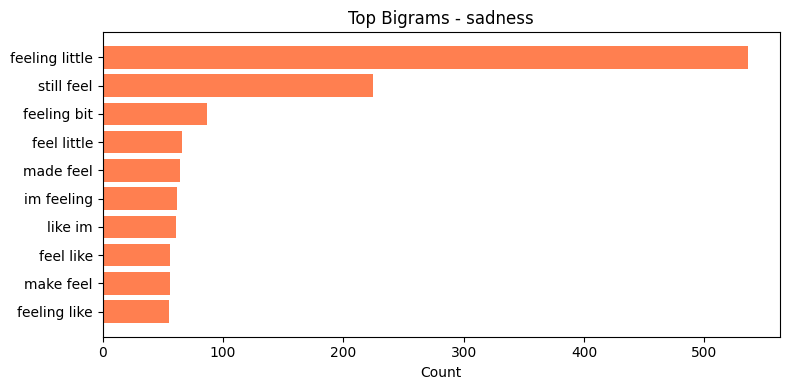

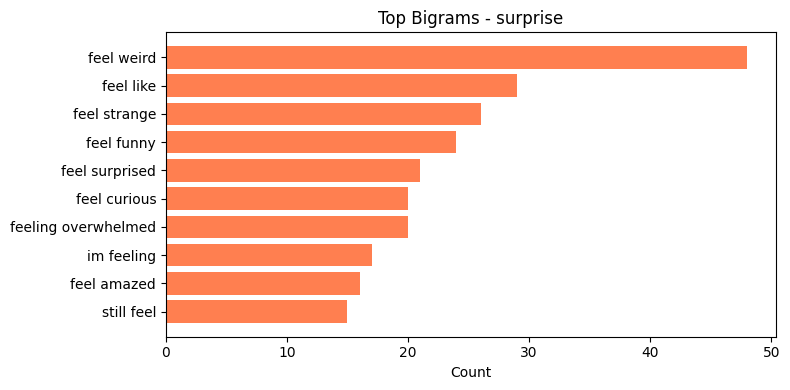


Top Bigrams per emotion done!


In [26]:
print('='*50)
print("  Part B - TASK 2: Top Bigrams per emotion")
print('='*50)

for emotion in emotion_labels:
    emotion_texts = df01_clean[df01_clean['labels']==emotion]['clean_text']

    bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=10)
    bigram_matrix = bigram_vec.fit_transform(emotion_texts)

    bigram_sums = bigram_matrix.sum(axis=0).A1
    bigram_words = list(bigram_vec.vocabulary_.keys())
    bigram_freq = sorted(zip(bigram_words, bigram_sums), key=lambda x: x[1], reverse=True)

    words = [items[0] for items in bigram_freq]
    counts = [items[1] for items in bigram_freq]
    
    with plt.style.context('default'):
     plt.figure(figsize=(8, 4))
     plt.barh(words[::-1], counts[::-1], color='coral')
     plt.title(f'Top Bigrams - {emotion}')
     plt.xlabel('Count')
     plt.tight_layout()
     plt.show()
    

print()
print('='*50)
print("Top Bigrams per emotion done!")
print('='*50)

POS (Part-Of-Speech) Tagging Analysis

  Part B - TASK 2: POS (Part-Of-Speech) Tagging Analysis

POS Distribution (%) Per Emotion:



,Noun,Verb,Adjective,Adverb
anger,44.1,27.0,19.4,9.5
fear,42.0,24.7,23.1,10.1
joy,44.0,24.5,22.3,9.3
love,45.0,25.6,20.3,9.1
sadness,42.0,27.1,21.0,9.9
surprise,41.0,28.0,21.1,9.9


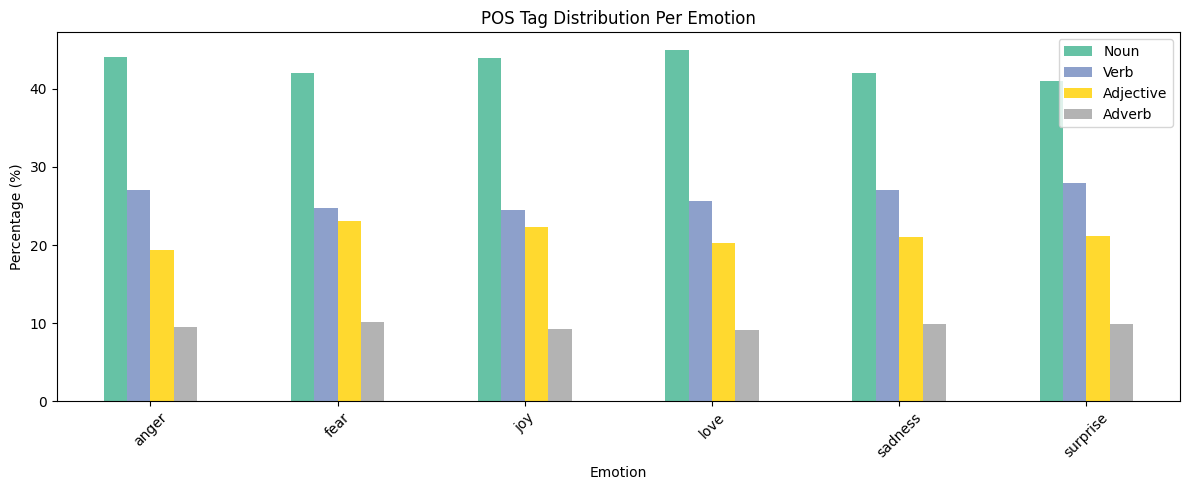


POS Tagging Analysis done!


In [27]:
print('='*60)
print("  Part B - TASK 2: POS (Part-Of-Speech) Tagging Analysis")
print('='*60)

pos_map = {
    'JJ':'Adjective', 'JJR':'Adjective', 'JJS':'Adjective',
    'VB':'Verb', 'VBD':'Verb', 'VBG':'Verb', 'VBN':'Verb',
    'VBP':'Verb', 'VBZ':'Verb', 'NN':'Noun', 'NNS':'Noun',
    'NNP':'Noun', 'RB':'Adverb', 'RBR':'Adverb', 'RBS':'Adverb'       
           }

pos_summary = {}

for emotion in emotion_labels:
    emotion_texts = df01_clean[df01_clean['labels']==emotion]['clean_text'].head(200)
    
    counts = Counter()
    
    for text in emotion_texts:
        tokens = word_tokenize(text)
        tags = nltk.pos_tag(tokens)

        for word, tag in tags:
            simplified = pos_map.get(tag, None)
            if simplified:
                counts[simplified] += 1

    total = sum(counts.values())
    pos_summary[emotion] = {pos: round(count / total*100, 1) for pos, count in counts.items()}

pos_df = pd.DataFrame(pos_summary).T.fillna(0)
print("\nPOS Distribution (%) Per Emotion:\n")
display(pos_df)

with plt.style.context('default'):
  pos_df.plot(kind='bar', figsize=(12, 5), colormap='Set2')
  plt.title('POS Tag Distribution Per Emotion')
  plt.xlabel('Emotion')
  plt.ylabel('Percentage (%)')
  plt.xticks(rotation=45)
  plt.legend(loc='upper right')
  plt.tight_layout()
  plt.show()

print()
print('='*50)
print("POS Tagging Analysis done!")
print('='*50)

## **PART B - TASK 3: Improved Cleaning**

In [28]:
print('='*50)
print("  Part B - TASK 3: Improved Cleaning")
print('='*50)

df01_improved = df01.copy()
df01_improved['clean_text'] = df01_improved['text'].apply(process_with_lemm)

df02_improved = df02.copy()
df02_improved['clean_text'] = df02_improved['text'].apply(process_with_lemm)

df03_improved = df03.copy()
df03_improved['clean_text'] = df03_improved['text'].apply(process_with_lemm)

print('='*50)
print("Improved Cleaning done!")
print('='*50)

  Part B - TASK 3: Improved Cleaning
Improved Cleaning done!


## **PART B - TASK 4: Retrain**

In [29]:
print('='*50)
print("  Part B - TASK 4: Retrain and Revectorize")
print('='*50)

#Vectorize improved data
tfidf_improved = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_imp = tfidf_improved.fit_transform(df01_improved['clean_text'])
X_val_imp = tfidf_improved.transform(df02_improved['clean_text'])
X_test_imp = tfidf_improved.transform(df03_improved['clean_text'])

y_train_imp = pd.get_dummies(df01_improved['labels'])
y_val_imp = pd.get_dummies(df02_improved['labels'])
y_test_imp = pd.get_dummies(df03_improved['labels'])

print("X_train_imp shape:", X_train_imp.shape)
print("y_train_imp shape:", y_train_imp.shape)
print()

print('='*50)
print("Vectorize Improved data done!")
print('='*50)

  Part B - TASK 4: Retrain and Revectorize
X_train_imp shape: (16000, 5000)
y_train_imp shape: (16000, 6)

Vectorize Improved data done!


In [30]:
#Improved Sequential Model
model_improved = Sequential()

model_improved.add(Dense(64, input_dim=X_train_imp.shape[1], activation='relu'))

model_improved.add(Dense(6, activation='softmax'))

model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print('='*60)
print("Improved Sequential Model created, compiled and ready for training")
print('='*60)

Improved Sequential Model created, compiled and ready for training


c:\Users\Zach Ng\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
num_epochs = 5
history_imp = model_improved.fit(X_train_imp, y_train_imp, epochs=num_epochs, validation_data=(X_val_imp, y_val_imp))

print()
print('='*50)
print("  Training of Improved Model Complete")
print('='*50)
print()
print('='*50)
print("Retrain the Model completed!")
print('='*50)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6473 - loss: 1.1459 - val_accuracy: 0.8540 - val_loss: 0.5680
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9234 - loss: 0.3148 - val_accuracy: 0.9025 - val_loss: 0.3035
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9654 - loss: 0.1460 - val_accuracy: 0.8995 - val_loss: 0.2684
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9817 - loss: 0.0899 - val_accuracy: 0.9020 - val_loss: 0.2607
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9877 - loss: 0.0608 - val_accuracy: 0.9025 - val_loss: 0.2710

  Training of Improved Model Complete

Retrain the Model completed!


## **PART B - TASK 5: Evaluation & Comparison**

  Part B - TASK 5: Evaluation & Comparison

  Part B - Task 5: Plot Curves of Loss & Accuracy



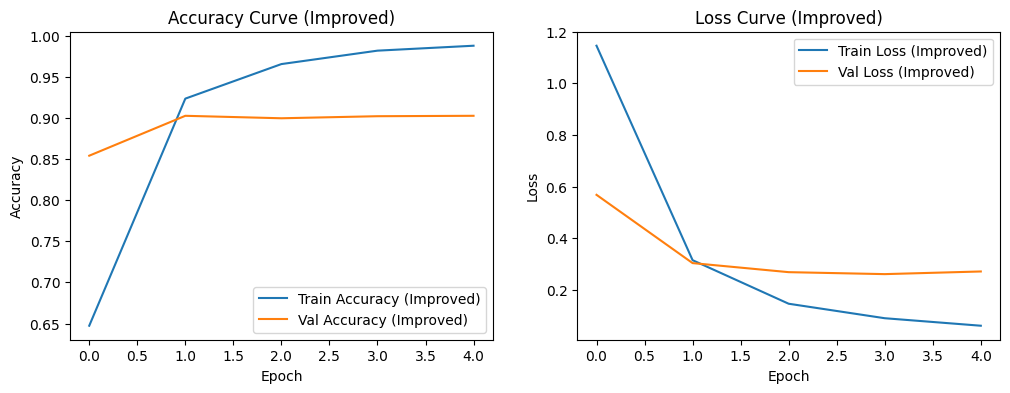

In [32]:
print('='*50)
print("  Part B - TASK 5: Evaluation & Comparison")
print('='*50)
print()

print('='*50)
print("  Part B - Task 5: Plot Curves of Loss & Accuracy")
print('='*50)
print()

#Create the Plot Curves

with plt.style.context('default'):
  #Accuracy Curves
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history_imp.history['accuracy'], label='Train Accuracy (Improved)')
  plt.plot(history_imp.history['val_accuracy'], label='Val Accuracy (Improved)')
  plt.title('Accuracy Curve (Improved)')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

#Loss Curves
  plt.subplot(1, 2, 2)
  plt.plot(history_imp.history['loss'], label='Train Loss (Improved)')
  plt.plot(history_imp.history['val_loss'], label='Val Loss (Improved)')
  plt.title('Loss Curve (Improved)')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

plt.show()

In [33]:
print('='*50)
print("  Part B - Task 5: Predictions")
print('='*50)
print()

preds_imp = model_improved.predict(X_test_imp)
preds_imp_cm = [np.argmax(each) for each in preds_imp]

y_preds_imp_cm = [np.argmax(each) for each in y_test_imp.values]
print(y_preds_imp_cm)

print('='*50)
print("Predictions done!")
print('='*50)

  Part B - Task 5: Predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(4), np.int64(0), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(0), np.int64(4), np.int64(2), np.int64(4), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(4), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(5), np.int64(4), np.int64(0), np.int64(1), np.int64(5), np.int64(2), np.in

In [34]:
print('='*50)
print("  Part B - Task 5: Confusion Matrix")
print('='*50)
print()

cm_imp = confusion_matrix(y_preds_imp_cm, preds_imp_cm)
df_cm_imp = pd.DataFrame(cm_imp, index=emotion_labels, columns=emotion_labels)
print("Confusion Matrix (Improved Model):")
display(df_cm_imp)

print('='*50)
print("Confusion Matrix set and done!")
print('='*50)

  Part B - Task 5: Confusion Matrix

Confusion Matrix (Improved Model):


,anger,fear,joy,love,sadness,surprise
anger,236,7,7,2,23,0
fear,10,183,7,0,14,10
joy,2,2,653,27,7,4
love,2,0,31,122,4,0
sadness,15,6,11,2,547,0
surprise,1,11,10,0,2,42


Confusion Matrix set and done!


  Part B - Task 5: Confusion Matrix Heatmap



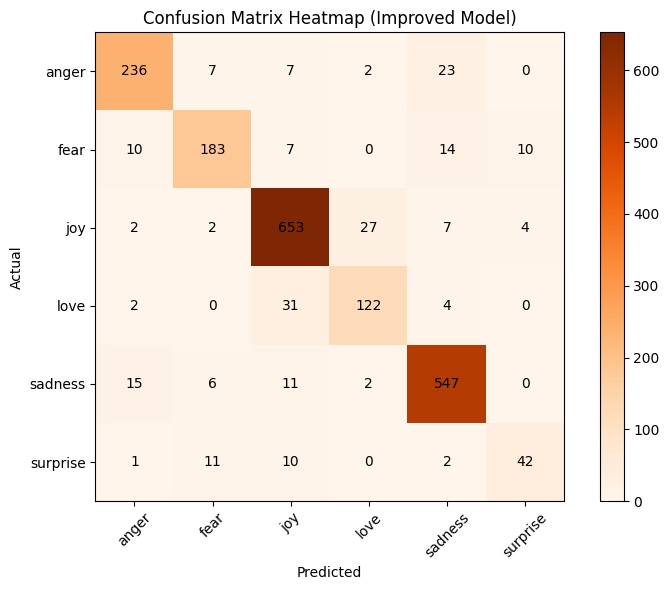

Confusion Matrix Heatmap (Improved Model) done!


In [35]:
print('='*50)
print("  Part B - Task 5: Confusion Matrix Heatmap")
print('='*50)
print()

with plt.style.context('default'):
  plt.figure(figsize=(8, 6))
  plt.imshow(cm_imp, cmap='Oranges')
  plt.colorbar()
  plt.xticks(range(6), emotion_labels, rotation=45)
  plt.yticks(range(6), emotion_labels)
  for i in range(6):
      for j in range(6):
        plt.text(j, i, cm_imp[i, j], ha='center', va='center', color='black')
  plt.title('Confusion Matrix Heatmap (Improved Model)')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.tight_layout()
  plt.show()

print('='*50)
print("Confusion Matrix Heatmap (Improved Model) done!")
print('='*50)

  Part B - Task 5: Compare Baseline & Improved Model

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8775 - loss: 0.3244
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8915 - loss: 0.2670
Baseline Accuracy (Part A): 0.8775 (87.75%)
Improved Accuracy (Part B): 0.8915 (89.15%)
Difference: 1.4%


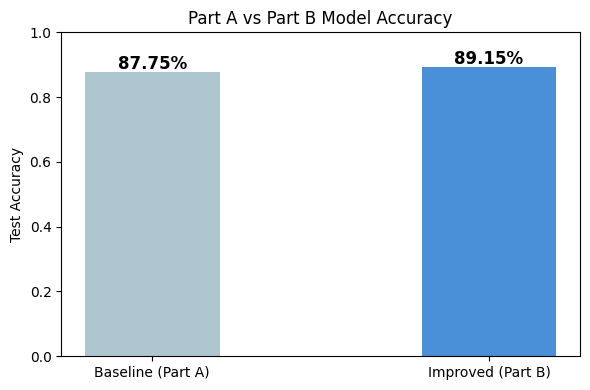


Comparison Done!


In [36]:
print('='*50)
print("  Part B - Task 5: Compare Baseline & Improved Model")
print('='*50)
print()

loss, accuracy = model.evaluate(X_test, y_test)
loss_imp, accuracy_imp = model_improved.evaluate(X_test_imp, y_test)

print(f"Baseline Accuracy (Part A): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Improved Accuracy (Part B): {accuracy_imp:.4f} ({accuracy_imp*100:.2f}%)")
print(f"Difference: {(accuracy_imp - accuracy)*100:.1f}%")

#Set the variables during plt.bar()
labels_comp = ['Baseline (Part A)', 'Improved (Part B)']
accs_comp = [accuracy, accuracy_imp]
color_comp = ['#aec6cf', '#4a90d9']

#Create the Bar Chart
with plt.style.context('default'):
  plt.figure(figsize=(6, 4))
  plt.bar(labels_comp, accs_comp, color=color_comp, width=0.4)
  plt.ylim(0, 1)
  plt.ylabel('Test Accuracy')
  plt.title('Part A vs Part B Model Accuracy')
  for i, acc in enumerate(accs_comp):
      plt.text(i, acc + 0.01, f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
  plt.tight_layout()
  plt.show()

print()
print('='*50)
print("Comparison Done!")
print('='*50)

In [37]:
print('='*50)
print("  Part B - Task 5: Classification Report")
print('='*50)
print()

print(classification_report(y_preds_imp_cm, preds_imp_cm, target_names=emotion_labels))

print()
print('='*50)
print("Classification Report loaded & done!")
print('='*50)
print()
print('='*50)
print("Evaluation & Comparison Done")
print('='*50)

  Part B - Task 5: Classification Report

              precision    recall  f1-score   support

       anger       0.89      0.86      0.87       275
        fear       0.88      0.82      0.85       224
         joy       0.91      0.94      0.92       695
        love       0.80      0.77      0.78       159
     sadness       0.92      0.94      0.93       581
    surprise       0.75      0.64      0.69        66

    accuracy                           0.89      2000
   macro avg       0.86      0.83      0.84      2000
weighted avg       0.89      0.89      0.89      2000


Classification Report loaded & done!

Evaluation & Comparison Done
